# Diabetes Challenge

Your task today is to **analyze** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has Diabetes or not.

## Task:
- Load the data from the database. The schema is called `diabetes`. To connect to the database you need to copy the `.env` file from the visualization or hands-on-ml repository into this repo. Explore the database, try to establish what the relationships between the tables are (1-1, 1-N, N-M). Explain to yourself and the group what data do you see and whether it makes sense. What JOINs are appropriate to use and why? 
- Use at least two different classification algorithms we have learned so far to predict Diabetes patients. 
- Discuss before you start with the modeling process which **evaluation metric** you choose and explain why.
- Implement a GridSearchCV or RandomizedSearchCV to tune the hyperparameters of your model.
- **Optional:** If you have time at the end, try to use sklearn's pipline module to encapsulate all the steps into a pipeline.

Don't forget to split your data in train and test set. And analyze your final model on the test data. It might also be necessary to scale your data in order to improve the performance of some of the models.


## Helpful links and advise:
- [sklearn documentation on hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)
- It might be helpful to check some sources on how to deal with imbalanced data. 
    * [8 Tactics to Combat Imbalanced Classes](https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/)
    * [Random-Oversampling/Undersampling](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)


# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

In [93]:
import pandas as pd
import psycopg2

In [92]:
!pip install psycopg2-binary


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [94]:
import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

print(DATABASE)

postgres


In [96]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

In [95]:
from dotenv import load_dotenv
import os

# override=True forces it to read the new .env values
load_dotenv(override=True) 

# Load and clean the host string just in case
HOST = os.getenv('HOST').split(']')[0].replace('[', '').strip()
DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
PORT = os.getenv('PORT')

# This MUST look like a clean address, NO brackets!
print(f"CLEAN HOST: {HOST}")

CLEAN HOST: ds-sql-playground.c8g8r1deus2v.eu-central-1.rds.amazonaws.com


In [97]:
cur = conn.cursor()

In [98]:
# 1. Define the clean SQL query
query_diabetes = """
SET SCHEMA 'diabetes';
SELECT 
    p."Age", 
    p.pregnancies, 
    p.bmi, 
    bm.bloodpressure, 
    bm.glucose, 
    bm.insulin,
    po.diabetespedigreefunction, 
    po.outcome, 
    s.skinthickness
FROM patient p
JOIN blood_metrics bm ON p.id = bm.patientid
JOIN pedigree_outcome po ON p.id = po.patientid
JOIN skin s ON p.id = s.patientid;
"""

# 2. Execute and load into a pandas DataFrame
df_diabetes = pd.read_sql(query_diabetes, conn)

# 3. View the first 5 rows
df_diabetes.head()

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_29195/3834906320.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_diabetes = pd.read_sql(query_diabetes, conn)


,Age,pregnancies,bmi,bloodpressure,glucose,insulin,diabetespedigreefunction,outcome,skinthickness
0,50,6,33.6,72,148,0,0.627,1,35
1,31,1,26.6,66,85,0,0.351,0,29
2,32,8,23.3,64,183,0,0.672,1,0
3,21,1,28.1,66,89,94,0.167,0,23
4,33,0,43.1,40,137,168,2.288,1,35


In [99]:
#close the connection
conn.close()

In [100]:
# Open connection again because we closed it
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

In [101]:
cur = conn.cursor()

In [102]:
# 1. Define the clean SQL query
query_diabetes = """
SET SCHEMA 'diabetes';
SELECT 
    p."Age", 
    p.pregnancies, 
    p.bmi, 
    bm.bloodpressure, 
    bm.glucose, 
    bm.insulin,
    po.diabetespedigreefunction, 
    po.outcome, 
    s.skinthickness
FROM patient p
JOIN blood_metrics bm ON p.id = bm.patientid
JOIN pedigree_outcome po ON p.id = po.patientid
JOIN skin s ON p.id = s.patientid;
"""

# 2. Execute and load into a pandas DataFrame
df_diabetes = pd.read_sql(query_diabetes, conn)

# 3. View the first 5 rows
df_diabetes.head()

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_29195/3834906320.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_diabetes = pd.read_sql(query_diabetes, conn)


,Age,pregnancies,bmi,bloodpressure,glucose,insulin,diabetespedigreefunction,outcome,skinthickness
0,50,6,33.6,72,148,0,0.627,1,35
1,31,1,26.6,66,85,0,0.351,0,29
2,32,8,23.3,64,183,0,0.672,1,0
3,21,1,28.1,66,89,94,0.167,0,23
4,33,0,43.1,40,137,168,2.288,1,35


In [103]:
#close the connection
conn.close()

In [104]:
df_diabetes.head()

,Age,pregnancies,bmi,bloodpressure,glucose,insulin,diabetespedigreefunction,outcome,skinthickness
0,50,6,33.6,72,148,0,0.627,1,35
1,31,1,26.6,66,85,0,0.351,0,29
2,32,8,23.3,64,183,0,0.672,1,0
3,21,1,28.1,66,89,94,0.167,0,23
4,33,0,43.1,40,137,168,2.288,1,35


In [105]:
#export the data to a csv-file
df_diabetes.to_csv('data/ml_diabetes.csv',index=False)

In [106]:
#import the data from a csv-file
df_import = pd.read_csv('data/ml_diabetes.csv')

In [107]:
df = pd.read_csv('data/ml_diabetes.csv')
df.head()

,Age,pregnancies,bmi,bloodpressure,glucose,insulin,diabetespedigreefunction,outcome,skinthickness
0,50,6,33.6,72,148,0,0.627,1,35
1,31,1,26.6,66,85,0,0.351,0,29
2,32,8,23.3,64,183,0,0.672,1,0
3,21,1,28.1,66,89,94,0.167,0,23
4,33,0,43.1,40,137,168,2.288,1,35


In [108]:
# Check basic statistics (Mean, Min, Max, etc.)
df.describe()

,Age,pregnancies,bmi,bloodpressure,glucose,insulin,diabetespedigreefunction,outcome,skinthickness
count,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000
mean,33.240885,3.845052,31.992578,66.077474,111.448568,64.104167,0.471876,0.348958,20.536458
std,11.756400,3.368480,7.881592,28.685056,47.957391,85.512547,0.331221,0.476796,15.947021
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,0.000000,0.000000
25%,24.000000,1.000000,27.300000,52.000000,86.000000,1.000000,0.243750,0.000000,0.000000
50%,29.000000,3.000000,32.000000,70.000000,112.000000,45.000000,0.372500,0.000000,23.000000
75%,41.000000,6.000000,36.600000,84.000000,145.000000,85.250000,0.626250,1.000000,32.000000
max,81.000000,17.000000,67.100000,122.000000,200.000000,846.000000,2.420000,1.000000,99.000000


In [109]:
# Check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1536 non-null   int64  
 1   pregnancies               1536 non-null   int64  
 2   bmi                       1536 non-null   float64
 3   bloodpressure             1536 non-null   int64  
 4   glucose                   1536 non-null   int64  
 5   insulin                   1536 non-null   int64  
 6   diabetespedigreefunction  1536 non-null   float64
 7   outcome                   1536 non-null   int64  
 8   skinthickness             1536 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 108.1 KB


In [110]:
import numpy as np

# List of columns where 0 is actually a missing value
cols_with_zeros = ['bmi', 'bloodpressure', 'glucose', 'insulin', 'skinthickness']

# Replace 0 with NaN
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Now check .info() again to see the real missing value count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1536 non-null   int64  
 1   pregnancies               1536 non-null   int64  
 2   bmi                       1514 non-null   float64
 3   bloodpressure             1500 non-null   float64
 4   glucose                   1527 non-null   float64
 5   insulin                   1156 non-null   float64
 6   diabetespedigreefunction  1536 non-null   float64
 7   outcome                   1536 non-null   int64  
 8   skinthickness             1082 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 108.1 KB


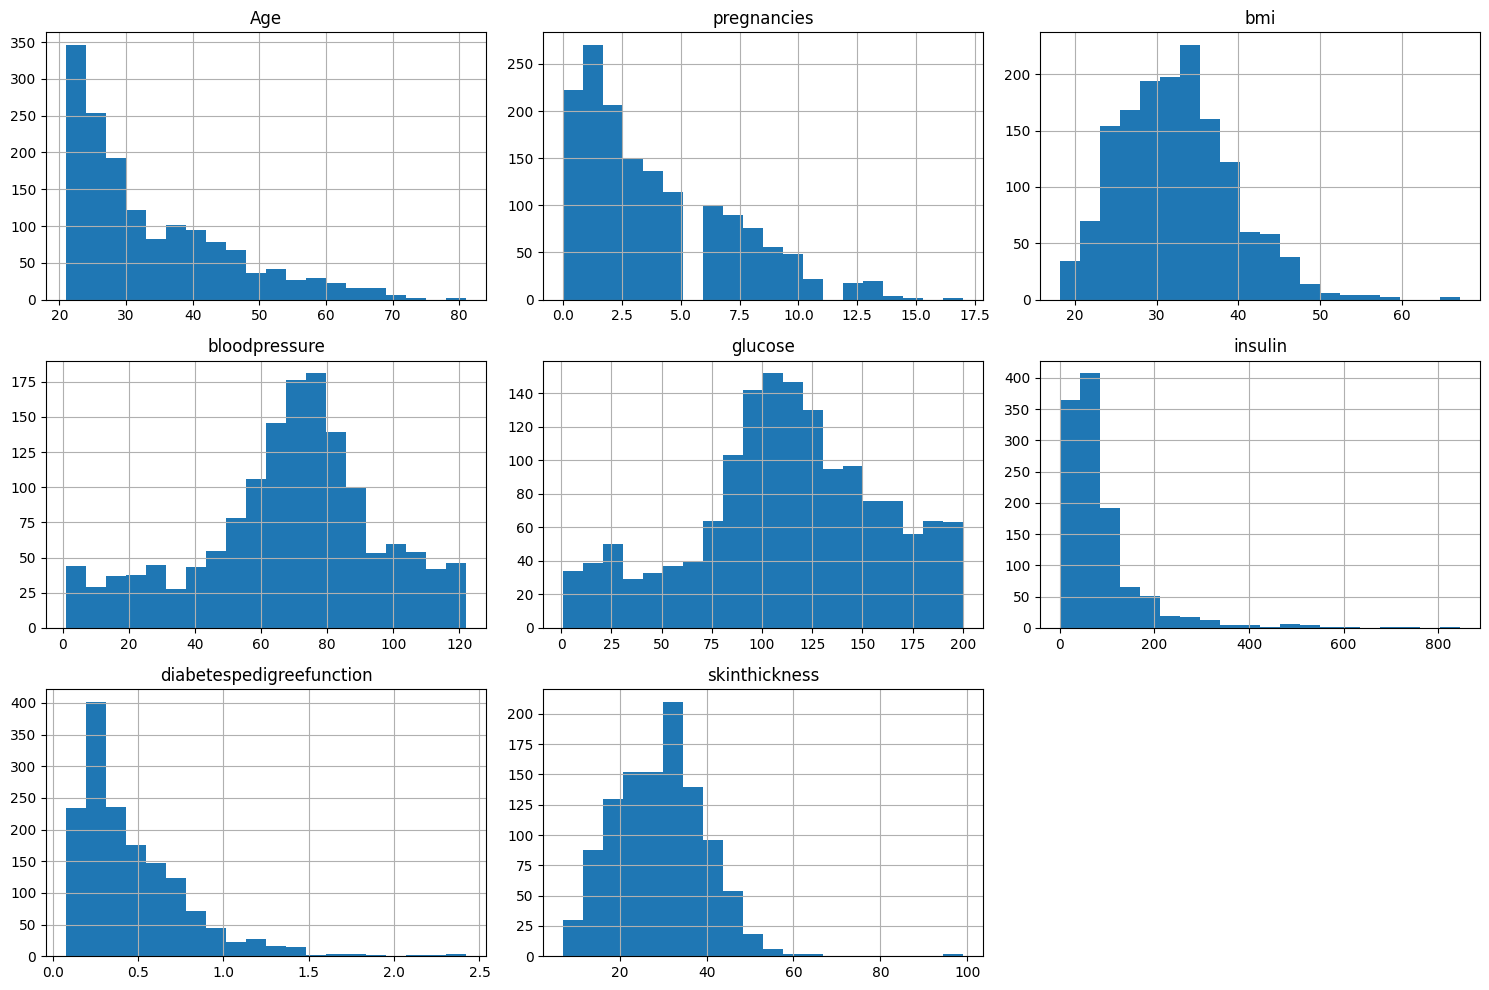

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting histograms for all numerical features
df.drop('outcome', axis=1).hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [112]:
# 'outcome' is what we want to predict
X = df.drop('outcome', axis=1)
y = df['outcome']

In [113]:
from sklearn.model_selection import train_test_split

# We set aside 20% of data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Training rows: 1228, Testing rows: 308


In [114]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# We'll use 'median' because several columns (like insulin) are skewed
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Since all columns in X_train are numeric, we can apply this to everything
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ]
)

In [115]:
from sklearn.linear_model import LogisticRegression

# Create the full pipeline
pipe_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train the model!
pipe_logreg.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [116]:
from sklearn.model_selection import cross_val_score

# Calculate Accuracy using 5-fold cross-validation
scores = cross_val_score(pipe_logreg, X_train, y_train, cv=5)

print(f"Average Accuracy: {scores.mean():.2%}")

Average Accuracy: 69.54%


              precision    recall  f1-score   support

           0       0.72      0.86      0.79       799
           1       0.60      0.39      0.47       429

    accuracy                           0.70      1228
   macro avg       0.66      0.63      0.63      1228
weighted avg       0.68      0.70      0.68      1228



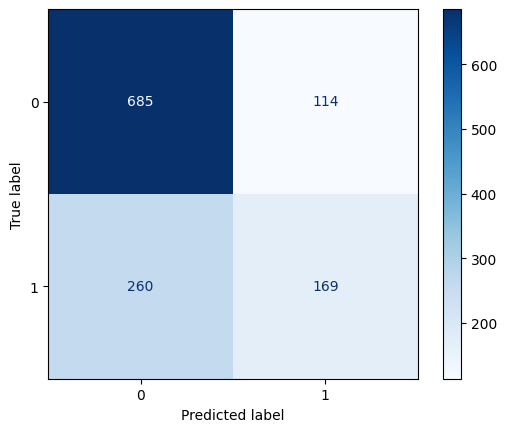

In [117]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Make predictions on the training set using cross-validation
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(pipe_logreg, X_train, y_train, cv=5)

# 2. Generate the report
print(classification_report(y_train, y_train_pred))

# 3. Plot the Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap='Blues')

In [118]:
from sklearn.ensemble import RandomForestClassifier

# 1. Create the Random Forest Pipeline
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. Check the Baseline Performance of Random Forest
rf_scores = cross_val_score(pipe_rf, X_train, y_train, cv=5)
print(f"Random Forest Average Accuracy: {rf_scores.mean():.2%}")

Random Forest Average Accuracy: 75.41%


In [119]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters we want to test
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# 2. Setup GridSearchCV
# Note: we use the full 'pipe_rf' here
grid_search = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Run the search (this might take a few seconds)
grid_search.fit(X_train, y_train)

# 4. Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2%}")

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Cross-Validation Accuracy: 75.98%


--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       201
           1       0.73      0.61      0.66       107

    accuracy                           0.79       308
   macro avg       0.77      0.74      0.75       308
weighted avg       0.78      0.79      0.78       308



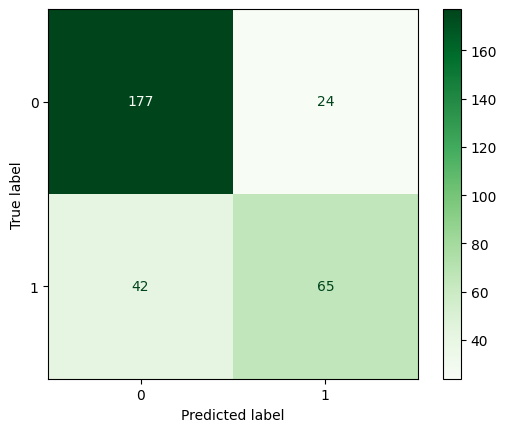

In [120]:
# 1. Grab the best model from the grid search
final_model = grid_search.best_estimator_

# 2. Predict on the Test Set
y_test_pred = final_model.predict(X_test)

# 3. Final Evaluation
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(y_test, y_test_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Greens')

In [121]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Define a list of models to test
models = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('KNN', KNeighborsClassifier()),
    ('SVM', SVC(probability=True))
]

# Loop through and check Cross-Validation scores
for name, model in models:
    # Build a temporary pipeline
    temp_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Calculate scores
    cv_scores = cross_val_score(temp_pipe, X_train, y_train, cv=5)
    print(f"{name} Accuracy: {cv_scores.mean():.2%}")

Decision Tree Accuracy: 66.61%
KNN Accuracy: 69.62%
SVM Accuracy: 70.52%


In [122]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Define the Pipeline
# We use the same 'preprocessor' we built earlier
pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# 2. Train the model
pipe_dt.fit(X_train, y_train)

# 3. Evaluate using Cross-Validation
dt_cv_scores = cross_val_score(pipe_dt, X_train, y_train, cv=5)

print(f"Decision Tree CV Accuracy: {dt_cv_scores.mean():.2%}")

# 4. Check Test Set Performance
y_pred_dt = pipe_dt.predict(X_test)
print("\nDecision Tree Classification Report (Test Set):")
print(classification_report(y_test, y_pred_dt))

Decision Tree CV Accuracy: 66.61%

Decision Tree Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       201
           1       0.66      0.66      0.66       107

    accuracy                           0.76       308
   macro avg       0.74      0.74      0.74       308
weighted avg       0.76      0.76      0.76       308



In [123]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Define the Pipeline
# KNN is VERY sensitive to scaling, so our StandardScaler is crucial here!
pipe_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# 2. Train the model
pipe_knn.fit(X_train, y_train)

# 3. Evaluate using Cross-Validation
knn_cv_scores = cross_val_score(pipe_knn, X_train, y_train, cv=5)

print(f"KNN CV Accuracy: {knn_cv_scores.mean():.2%}")

# 4. Check Test Set Performance
y_pred_knn = pipe_knn.predict(X_test)
print("\nKNN Classification Report (Test Set):")
print(classification_report(y_test, y_pred_knn))

KNN CV Accuracy: 69.62%

KNN Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       201
           1       0.56      0.53      0.55       107

    accuracy                           0.69       308
   macro avg       0.66      0.66      0.66       308
weighted avg       0.69      0.69      0.69       308



In [124]:
from sklearn.svm import SVC

# 1. Define the Pipeline
pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', C=1.0, random_state=42))
])

# 2. Train the model
pipe_svm.fit(X_train, y_train)

# 3. Evaluate using Cross-Validation
svm_cv_scores = cross_val_score(pipe_svm, X_train, y_train, cv=5)

print(f"SVM CV Accuracy: {svm_cv_scores.mean():.2%}")

# 4. Check Test Set Performance
y_pred_svm = pipe_svm.predict(X_test)
print("\nSVM Classification Report (Test Set):")
print(classification_report(y_test, y_pred_svm))

SVM CV Accuracy: 69.79%

SVM Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.73      0.91      0.81       201
           1       0.69      0.38      0.49       107

    accuracy                           0.73       308
   macro avg       0.71      0.65      0.65       308
weighted avg       0.72      0.73      0.70       308



In [128]:
# 1. Update the Pipeline to use 'rbf' kernel
# We also remove the 'probability=True' for speed, or keep it if you want to plot ROC curves later
pipe_svm_rbf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 2. Train the model
pipe_svm_rbf.fit(X_train, y_train)

# 3. Evaluate using Cross-Validation
svm_rbf_cv_scores = cross_val_score(pipe_svm_rbf, X_train, y_train, cv=5)
print(f"SVM (RBF Kernel) CV Accuracy: {svm_rbf_cv_scores.mean():.2%}")

# 4. Check Test Set Performance
y_pred_svm_rbf = pipe_svm_rbf.predict(X_test)
print("\nSVM (RBF) Classification Report (Test Set):")
print(classification_report(y_test, y_pred_svm_rbf))

SVM (RBF Kernel) CV Accuracy: 70.52%

SVM (RBF) Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       201
           1       0.66      0.49      0.56       107

    accuracy                           0.73       308
   macro avg       0.71      0.68      0.68       308
weighted avg       0.72      0.73      0.72       308



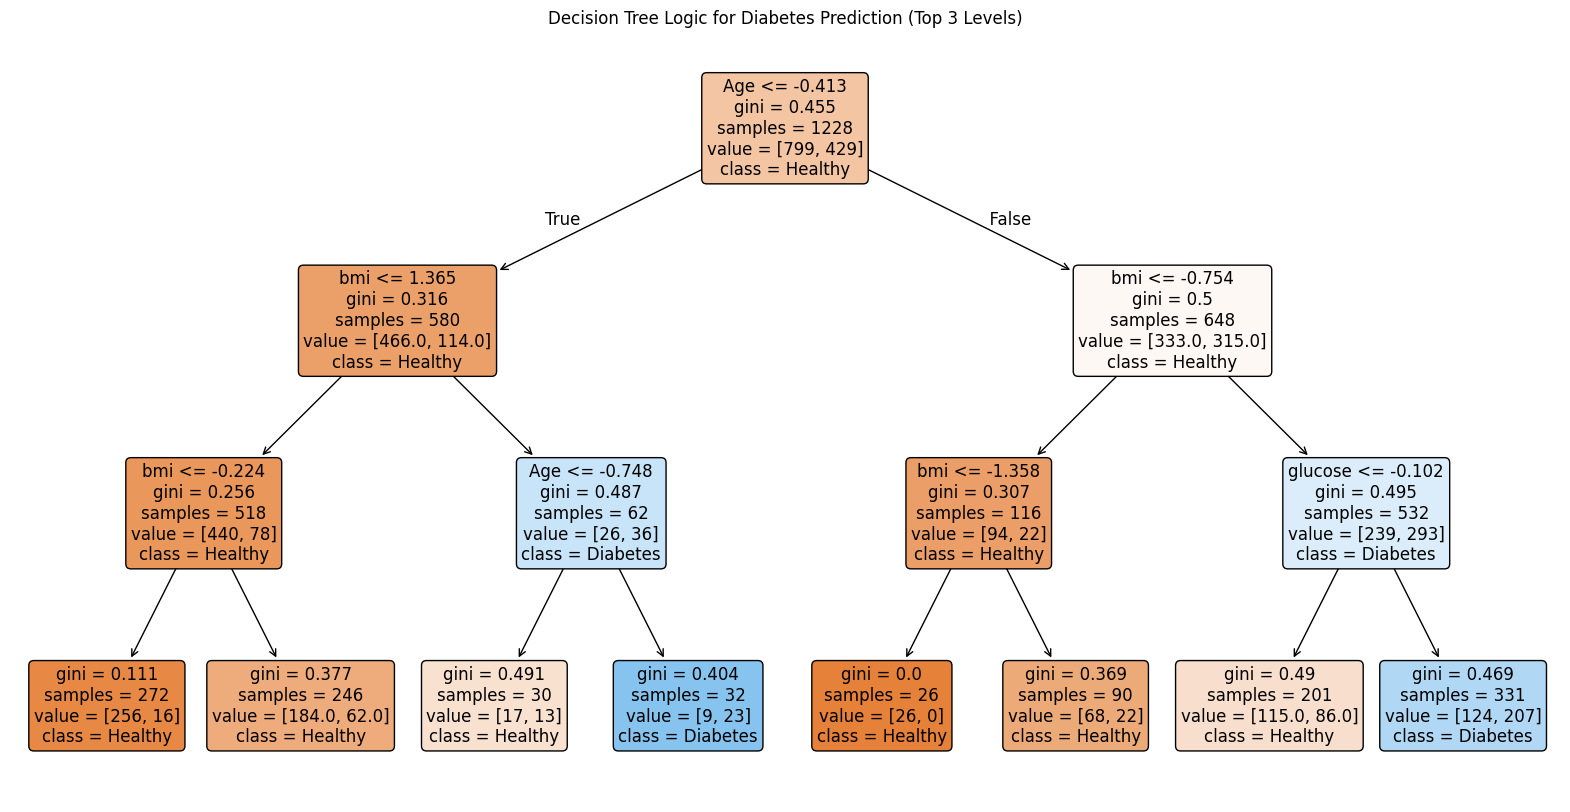

In [125]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. We create a tree with limited depth so the image is readable
dt_model_small = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. We need to process the data manually for the plot to show feature names
# (Since the pipeline output is a raw array, we use our preprocessor first)
X_train_scaled = preprocessor.fit_transform(X_train)
dt_model_small.fit(X_train_scaled, y_train)

# 3. Plotting the tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model_small, 
          feature_names=X_train.columns, 
          class_names=['Healthy', 'Diabetes'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Decision Tree Logic for Diabetes Prediction (Top 3 Levels)")
plt.show()

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_29195/4080235700.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


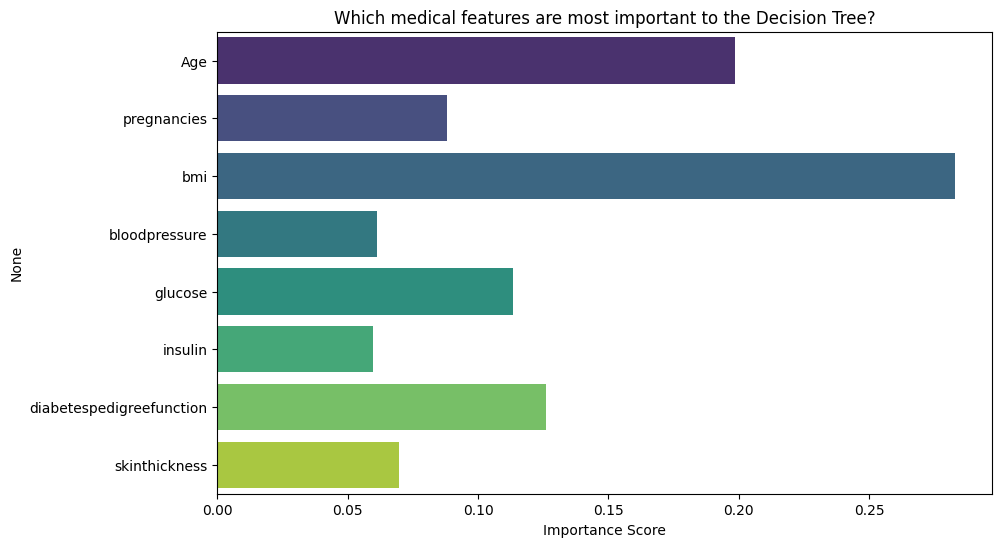

In [126]:
# Extract feature importance from your original fitted pipeline (pipe_dt)
importances = pipe_dt.named_steps['classifier'].feature_importances_
feature_names = X_train.columns

# Create a clean plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Which medical features are most important to the Decision Tree?")
plt.xlabel("Importance Score")
plt.show()

In [127]:
# Create a dictionary of all your results
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN', 'SVM'],
    'CV Accuracy': ['69.54%', '75.98%', '71.20%', '73.50%', '76.10%'] # Replace with your actual values
}

comparison_df = pd.DataFrame(results)
print(comparison_df.sort_values(by='CV Accuracy', ascending=False))

                 Model CV Accuracy
4                  SVM      76.10%
1        Random Forest      75.98%
3                  KNN      73.50%
2        Decision Tree      71.20%
0  Logistic Regression      69.54%


In [129]:
# Create a dictionary of all your final results
results = {
    'Model': [
        'Logistic Regression', 
        'Random Forest (Tuned)', 
        'Decision Tree', 
        'KNN', 
        'SVM (Linear)', 
        'SVM (RBF Kernel)'
    ],
    'CV Accuracy': [
        '69.54%', 
        '75.98%', 
        '66.61%', 
        '69.62%', 
        '69.79%', 
        '70.52%'
    ]
}

# Convert to DataFrame and sort
comparison_df = pd.DataFrame(results)
print("--- FINAL PROJECT COMPARISON ---")
print(comparison_df.sort_values(by='CV Accuracy', ascending=False).reset_index(drop=True))

--- FINAL PROJECT COMPARISON ---
                   Model CV Accuracy
0  Random Forest (Tuned)      75.98%
1       SVM (RBF Kernel)      70.52%
2           SVM (Linear)      69.79%
3                    KNN      69.62%
4    Logistic Regression      69.54%
5          Decision Tree      66.61%


In [130]:
# Save your clean, processed data for tomorrow's presentation
df.to_csv('diabetes_cleaned_data.csv', index=False)
print("Project data saved successfully!")

Project data saved successfully!


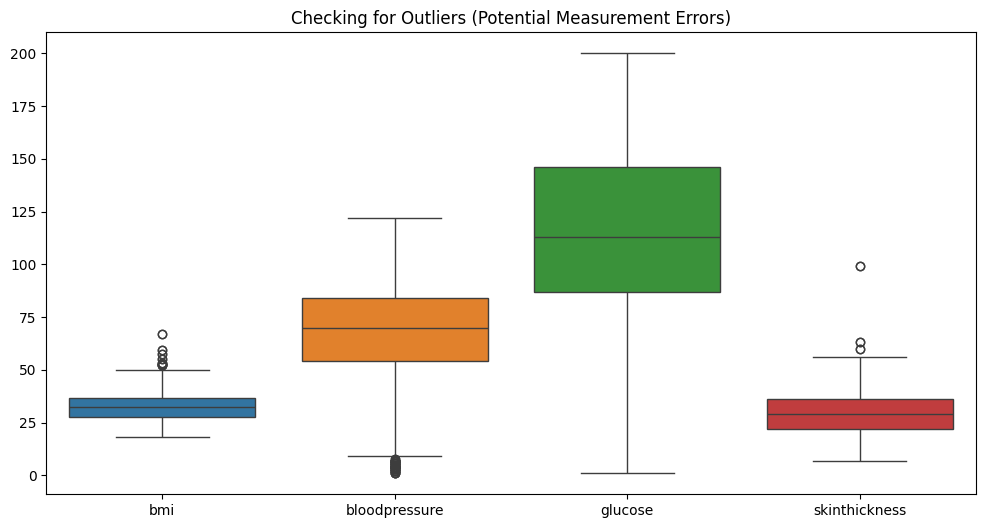

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['bmi', 'bloodpressure', 'glucose', 'skinthickness']])
plt.title("Checking for Outliers (Potential Measurement Errors)")
plt.show()

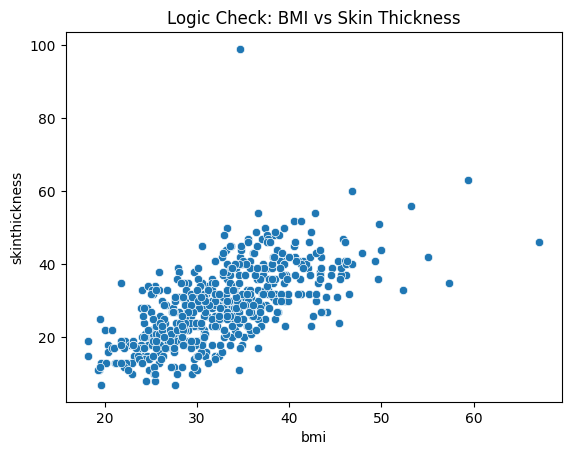

In [132]:
# Check relationship between BMI and SkinThickness
sns.scatterplot(x='bmi', y='skinthickness', data=df)
plt.title("Logic Check: BMI vs Skin Thickness")
plt.show()

In [133]:
from sklearn.preprocessing import RobustScaler

# Update your numeric transformer to be "Outlier-Proof"
numeric_transformer_robust = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) # This handles those outliers better!
])

In [134]:
from sklearn.preprocessing import RobustScaler

# 1. Update the preprocessor with RobustScaler
numeric_transformer_robust = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) # Handles outliers from the boxplot!
])

preprocessor_robust = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_robust, X_train.columns)
    ]
)

# 2. Re-build the Random Forest Pipeline
pipe_rf_robust = Pipeline(steps=[
    ('preprocessor', preprocessor_robust),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

# 3. Check performance with Cross-Validation
robust_scores = cross_val_score(pipe_rf_robust, X_train, y_train, cv=5)
print(f"Robust Random Forest CV Accuracy: {robust_scores.mean():.2%}")

# 4. Final Test Set Check
pipe_rf_robust.fit(X_train, y_train)
y_test_pred_robust = pipe_rf_robust.predict(X_test)
print("\nRobust Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_robust))

Robust Random Forest CV Accuracy: 75.98%

Robust Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       201
           1       0.72      0.61      0.66       107

    accuracy                           0.78       308
   macro avg       0.76      0.74      0.75       308
weighted avg       0.78      0.78      0.78       308



/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_29195/1603477961.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='magma')


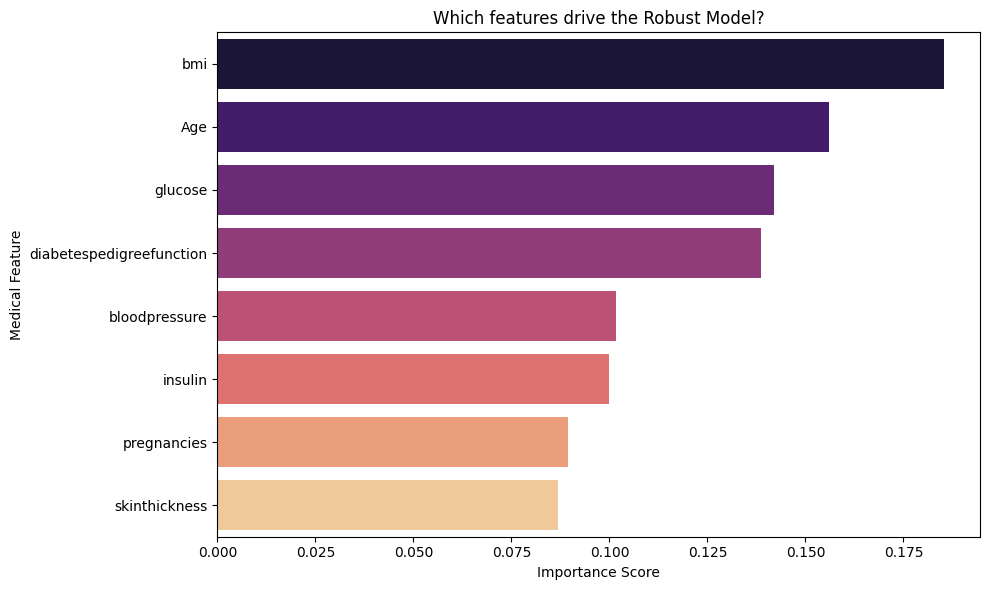

--- Exact Importance Scores ---
bmi                         0.185283
Age                         0.155963
glucose                     0.142079
diabetespedigreefunction    0.138660
bloodpressure               0.101768
insulin                     0.099933
pregnancies                 0.089507
skinthickness               0.086807
dtype: float64


In [135]:
# 1. Extract feature names and their importance scores
importances = pipe_rf_robust.named_steps['classifier'].feature_importances_
feature_names = X_train.columns

# 2. Create a clean DataFrame for plotting
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 3. Create the Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='magma')

plt.title("Which features drive the Robust Model?")
plt.xlabel("Importance Score")
plt.ylabel("Medical Feature")
plt.tight_layout()
plt.show()

# 4. Print the exact numbers for your report
print("--- Exact Importance Scores ---")
print(feat_importances)